In [1]:
from mpi4py import MPI
import numpy as np
import gmsh

from dolfinx import fem, geometry, default_scalar_type
from dolfinx.io import gmsh as gmshio #, XDMFFile
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, create_vector
import ufl
from petsc4py import PETSc

from FEM_functions import plot_solution

from matplotlib import pyplot as plt

from pathlib import Path

In [2]:
# ----------------------------------------------------------------------
# 1. Parameters
# ----------------------------------------------------------------------
T         = 5.0          # final time (~ 5 membrane time constants, since r ~ 1)
num_steps = 500          # number of time steps
dt        = T / num_steps
theta     = 1.0          # 1.0 = backward Euler, 0.5 = Crank-Nicolson
h         = 0.0025       # target mesh size (space constant lambda ~ sqrt(a/r) ~ 0.32)
print(f"Target mesh size h = {h:.4f}  =>  expected number of vertices ~ {1/h**2:.0f}")
print(f"Time step dt = {dt:.4f}  =>  expected number of time steps ~ {T/dt:.0f}")

# Initial depolarization: Gaussian bump  u0 = A * exp(-|x - x0|^2 / (2 s^2))
A_stim, s_stim = 1.0, 0.12
x0, y0         = 0.4, 0.0        # off-centre so the wave meets the scar and the boundary

# Diffusivity a(x): healthy tissue with a low-conductivity "scar" patch.
# Stays >= a_scar > 0 everywhere  => uniform ellipticity (well-posedness).
# a_healthy, a_scar = 0.1, 0.01
# xa, ya, wa        = -0.3, 0.0, 0.2
# Diffusivity a(x): healthy tissue with anisotropic diffusion (different in x and y).
a1, a2 = 0.2, 0.15 # x-direction and y-direction [0.1,0.9] for a1, a2

# Reaction r(x): uniform leak / repolarization rate (>= 0 for the maximum principle).
r_value = 1.0

# grid_size     = 201
snapshot_times = np.asarray([0.0, 1.0, 2.0, 3.0, 4.0, 5.0], dtype=np.float64)

Target mesh size h = 0.0025  =>  expected number of vertices ~ 160000
Time step dt = 0.0100  =>  expected number of time steps ~ 500


In [3]:
results_dir = Path("comparison_results")
results_dir.mkdir(exist_ok=True)

In [4]:
# ----------------------------------------------------------------------
# 2. Mesh: unit disk via gmsh
# ----------------------------------------------------------------------
mesh_comm  = MPI.COMM_WORLD
model_rank = 0
gmsh.initialize()
if mesh_comm.rank == model_rank:
    gmsh.model.add("disk")
    disk = gmsh.model.occ.addDisk(0.0, 0.0, 0.0, 1.0, 1.0)   # centre (0,0,0), radii (1,1)
    gmsh.model.occ.synchronize()
    gmsh.model.addPhysicalGroup(2, [disk], tag=1)
    gmsh.option.setNumber("Mesh.MeshSizeMin", h)
    gmsh.option.setNumber("Mesh.MeshSizeMax", h)
    gmsh.model.mesh.generate(2)
    gmsh.write("monodomain_disk.msh")

mesh_data = gmshio.model_to_mesh(gmsh.model, mesh_comm, model_rank, gdim=2)
# DOLFINx >= 0.9 returns a MeshData object; <= 0.8 returns a (mesh, cell_tags, facet_tags) tuple
domain = mesh_data.mesh if hasattr(mesh_data, "mesh") else mesh_data[0]
gmsh.finalize()

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000662792s, CPU 0.000632s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 25.938s, CPU 40.6399s)
Info    : 582519 nodes 1165037 elements
Info    : Writing 'monodomain_disk.msh'...
Info    : Done writing 'monodomain_disk.msh'


In [5]:
# ----------------------------------------------------------------------
# 3. Function space and coefficients
# ----------------------------------------------------------------------
V = fem.functionspace(domain, ("Lagrange", 2))
x = ufl.SpatialCoordinate(domain)

# spatially varying diffusivity a(x, y)
# a_coeff = a_healthy - (a_healthy - a_scar) * ufl.exp(
#     -((x[0] - xa) ** 2 + (x[1] - ya) ** 2) / (2.0 * wa ** 2)
# )

a1_coeff = fem.Constant(domain, default_scalar_type(a1))
a2_coeff = fem.Constant(domain, default_scalar_type(a2))

D_coeff = ufl.as_matrix((
    (a1_coeff, 0.0),
    (0.0, a2_coeff),
))

# reaction coefficient (uniform here). To make it heterogeneous, replace with, e.g.:
#   r_coeff = 0.5 + 2.0 * ufl.exp(-((x[0]-xr)**2 + (x[1]-yr)**2)/(2*wr**2))
r_coeff = fem.Constant(domain, default_scalar_type(r_value))

dt_c    = fem.Constant(domain, default_scalar_type(dt))
theta_c = fem.Constant(domain, default_scalar_type(theta))

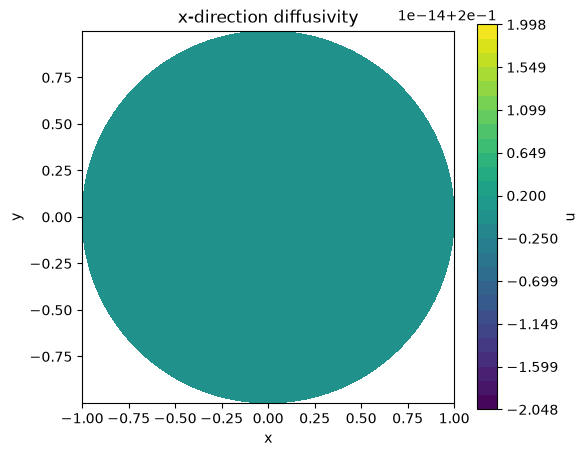

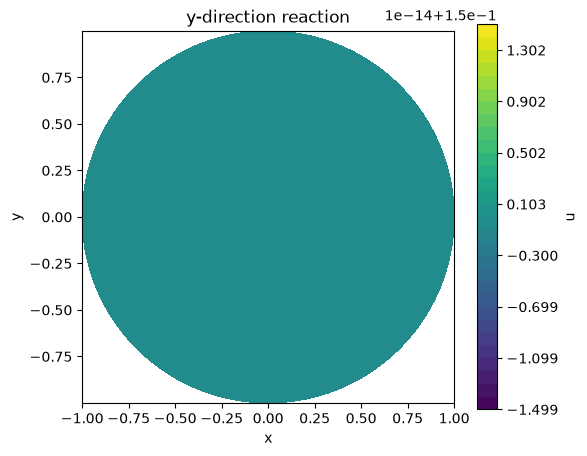

In [6]:
a1_plot = fem.Function(V)
a2_plot = fem.Function(V)
points = V.element.interpolation_points
points = points() if callable(points) else points
a1_plot.interpolate(fem.Expression(a1_coeff, points))
a2_plot.interpolate(fem.Expression(a2_coeff, points))
plot_solution(a1_plot,V, "x-direction diffusivity")
plot_solution(a2_plot,V, "y-direction reaction")

In [7]:
# ----------------------------------------------------------------------
# 4. Initial condition
# ----------------------------------------------------------------------
def u0_expr(x):
    return A_stim * np.exp(-((x[0] - x0) ** 2 + (x[1] - y0) ** 2) / (2.0 * s_stim ** 2))

u_n = fem.Function(V, name="u")     # solution at previous step
u_n.interpolate(u0_expr)

uh = fem.Function(V, name="u")      # solution at current step
uh.interpolate(u0_expr)

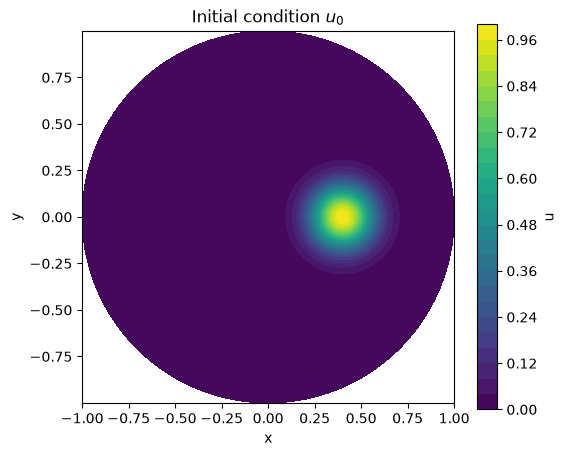

In [8]:
plot_solution(u_n,V, "Initial condition $u_0$")

In [9]:
# ----------------------------------------------------------------------
# 5. Variational forms (theta-scheme)
# ----------------------------------------------------------------------
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)

def B(w):   # weak spatial operator  (a grad w, grad v) + (r w, v)
    # return a_coeff * ufl.dot(ufl.grad(w), ufl.grad(v)) + r_coeff * w * v
    diffusion = ufl.inner(
        ufl.dot(D_coeff, ufl.grad(w)),
        ufl.grad(v),
    )
    reaction = r_coeff * w * v
    return diffusion + reaction

a_form = (u * v + dt_c * theta_c * B(u)) * ufl.dx
L_form = (u_n * v - dt_c * (1.0 - theta_c) * B(u_n)) * ufl.dx

bilinear_form = fem.form(a_form)
linear_form   = fem.form(L_form)

# Bilinear form is SPD (mass term + non-negative reaction), so the pure-Neumann
# system is non-singular: no Dirichlet BCs, no nullspace handling required.
A = assemble_matrix(bilinear_form)   # bcs default to [] (Neumann is natural)
A.assemble()
b = create_vector(V)

In [10]:
# ----------------------------------------------------------------------
# 6. Linear solver  (A is time-independent -> factor once, reuse)
# ----------------------------------------------------------------------
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(A)
solver.setType(PETSc.KSP.Type.PREONLY)
solver.getPC().setType(PETSc.PC.Type.LU)

In [11]:
# # ----------------------------------------------------------------------
# # 7. Output
# # ----------------------------------------------------------------------
# xdmf = XDMFFile(domain.comm, "monodomain_disk.xdmf", "w")
# xdmf.write_mesh(domain)
# xdmf.write_function(uh, 0.0)

In [12]:
points_xy = np.loadtxt(results_dir / "comparison_points.txt")

# DOLFINx evaluates points as (x, y, z)
eval_points = np.zeros((len(points_xy), 3), dtype=domain.geometry.x.dtype)
eval_points[:, :2] = points_xy

# Find the mesh cell containing each point—only done once
tree = geometry.bb_tree(
    domain,
    domain.topology.dim,
    padding=1.0e-10,
)
candidate_cells = geometry.compute_collisions_points(tree, eval_points)
colliding_cells = geometry.compute_colliding_cells(
    domain, candidate_cells, eval_points
)

point_cells = np.full(len(points_xy), -1, dtype=np.int32)
for i in range(len(points_xy)):
    cells = colliding_cells.links(i)
    if len(cells) > 0:
        point_cells[i] = cells[0]

inside = point_cells >= 0
print(f"{inside.sum()} of {len(inside)} points lie inside the FEM mesh")

def evaluate_at_comparison_points(u):
    """Evaluate a scalar FEM function at all comparison points."""
    values = np.full(len(points_xy), np.nan)

    values[inside] = np.asarray(
        u.eval(eval_points[inside], point_cells[inside])
    ).reshape(-1).real

    return values


# Convert requested times to integer step numbers
snapshot_steps = np.rint(snapshot_times / dt).astype(int)

if not np.allclose(snapshot_steps * dt, snapshot_times):
    raise ValueError("Some snapshot_times do not coincide with time steps")

snapshot_index_by_step = {
    step: i for i, step in enumerate(snapshot_steps)
}

# Shape: (number of times, number of spatial points)
snapshot_values = np.full(
    (len(snapshot_times), len(points_xy)),
    np.nan,
)

# Save initial condition at t = 0
if 0 in snapshot_index_by_step:
    snapshot_values[snapshot_index_by_step[0]] = (
        evaluate_at_comparison_points(u_n)
    )

7825 of 7825 points lie inside the FEM mesh


In [13]:
# ----------------------------------------------------------------------
# 8. Time-stepping
# ----------------------------------------------------------------------
t = 0.0
for n in range(num_steps):
    t += dt
    step = n + 1

    # assemble right-hand side
    with b.localForm() as loc:
        loc.set(0.0)
    assemble_vector(b, linear_form)
    b.ghostUpdate(
        addv=PETSc.InsertMode.ADD,
        mode=PETSc.ScatterMode.REVERSE,
    )

    # solve  A uh = b
    solver.solve(b, uh.x.petsc_vec)      # DOLFINx <= 0.7: use  uh.vector
    uh.x.scatter_forward()

    # Save requested snapshot
    if step in snapshot_index_by_step:
        snapshot_index = snapshot_index_by_step[step]
        snapshot_values[snapshot_index] = (
            evaluate_at_comparison_points(uh)
        )
        print(f"Stored snapshot at t = {t:.2f}")

    # advance:  u^n <- u^{n+1}
    u_n.x.array[:] = uh.x.array

    # if domain.comm.size == 1 and (n + 1) in snapshot_index_by_step:
    #     snapshot_index = snapshot_index_by_step[n + 1]
    #     snapshot_fields[snapshot_index] = sample_function(
    #         uh, sample_mask, sample_points, sample_cells
    #     )

    # diagnostics + output every 10 steps
#     if (n + 1) % 10 == 0:
#         umax = domain.comm.allreduce(np.max(np.abs(uh.x.array)), op=MPI.MAX)
#         if domain.comm.rank == 0:
#             print(f"step {n + 1:4d}   t = {t:5.2f}   max|u| = {umax:.4e}")
#         xdmf.write_function(uh, t)

# xdmf.close()

Stored snapshot at t = 1.00
Stored snapshot at t = 2.00
Stored snapshot at t = 3.00
Stored snapshot at t = 4.00
Stored snapshot at t = 5.00


In [14]:
output_file = results_dir / "fem_comparison_snapshots.npz"

np.savez_compressed(
    output_file,
    points=points_xy,              # shape: (n_points, 2)
    times=snapshot_times,          # shape: (n_times,)
    u=snapshot_values,             # shape: (n_times, n_points)
)

print(f"Saved results to {output_file}")

Saved results to comparison_results/fem_comparison_snapshots.npz


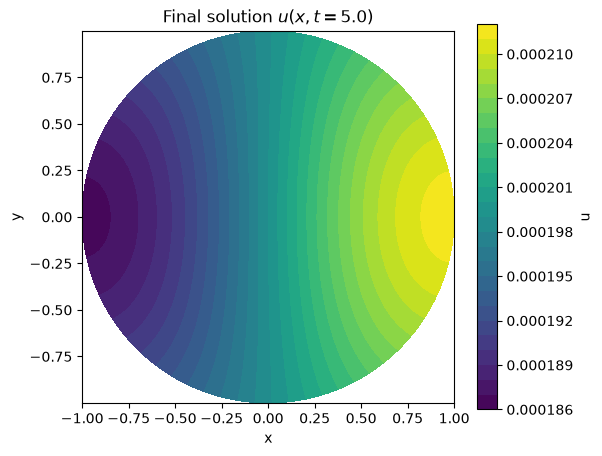

In [15]:
# ----------------------------------------------------------------------
# 9. Save final-state plot
# ----------------------------------------------------------------------
plot_solution(uh,V, f"Final solution $u(x, t={T})$")